# Physics-Informed Neural Network pour l'équation de la chaleur (problème inverse)

Dans ce notebook, nous utilisons un **Physics-Informed Neural Network (PINN)** pour estimer un **paramètre physique inconnu** dans l'équation de la chaleur 1D.

Le problème étudié est :

$$
u_t = \alpha u_{xx}
$$

où :

- \(u(t,x)\) : température
- \(t\) : temps
- \(x\) : position
- \(\alpha\) : diffusivité thermique

L'objectif est d'utiliser des **données bruitées de température** pour **retrouver la valeur du paramètre \(\alpha\)** à l'aide d'un PINN.

## 1. Génération des données de température

Les données de température sont générées à l'aide d'un **schéma aux différences finies implicite** pour résoudre l'équation de la chaleur :

$$
u_t = \alpha u_{xx}
$$

avec :

- domaine spatial : \(x \in [0,1]\)
- temps final : \(T = 1\)

Condition initiale :

$$
u(x,0) = \sin(\pi x)
$$

Conditions aux limites de Dirichlet :

$$
u(0,t) = 0, \quad u(1,t) = 0
$$

Afin de simuler des **mesures expérimentales**, un **bruit gaussien** est ajouté aux données :

$$
u_{bruit} = u + \epsilon
$$

avec :

$$
\epsilon \sim \mathcal{N}(0,\sigma)
$$

In [1]:
# =========================================================
# 1) GENERATION DU DATASET IMPLICITE + BRUIT
# =========================================================

import numpy as np
import pandas as pd
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

alpha = 0.3
L = 1.0
Tf = 1.0
N = 10000
ht = Tf / N

u0 = lambda x: np.sin(np.pi * x)

J = 200
x = np.linspace(0, L, J+1)
x_inner = x[1:-1]
hx = L / J

main_diag = (1 + 2*alpha*ht/hx**2) * np.ones(J-1)
off_diag  = (-alpha*ht/hx**2) * np.ones(J-2)
A = diags([off_diag, main_diag, off_diag], [-1,0,1]).tocsc()

temperature_data = []
header = ["Time (s)"] + [f"x={xi:.4f}m" for xi in x]
temperature_data.append(header)

U = np.zeros(J+1)
U[1:J] = u0(x_inner)

# bruit initial
bruit = 0.5
U_bruite = U + bruit * np.random.randn(len(U))
temperature_data.append([0.0] + U_bruite.tolist())

save_every = 50

for n in range(1, N+1):
    b = U[1:J]
    U_new_inner = spsolve(A, b)

    U[1:J] = U_new_inner
    U[0] = 0.0
    U[-1] = 0.0

    if n % save_every == 0 or n == N:
        U_bruite = U + bruit * np.random.randn(len(U))
        temperature_data.append([n * ht] + U_bruite.tolist())

df = pd.DataFrame(temperature_data[1:], columns=temperature_data[0])
df.to_csv("temperature_data_implicit_bruite.csv", index=False)

print("Fichier généré : temperature_data_implicit_bruite.csv")


Fichier généré : temperature_data_implicit_bruite.csv


## 2. Chargement et préparation des données

Les données générées précédemment sont stockées dans un fichier CSV.

Chaque ligne correspond à un instant donné et contient les températures mesurées le long de la barre.

Les données sont ensuite transformées en triplets :

$$
(t, x, u)
$$
qui serviront à entraîner le réseau de neurones.


## 3. Séparation des données

Les données sont séparées en :

- **données d'entraînement (80%)**
- **données de validation (20%)**

La validation permet de vérifier que le modèle ne sur-apprend pas les données d'entraînement.




## 4. Architecture du PINN

Nous utilisons un **réseau de neurones fully-connected** pour approximer la solution :

$$
u_\theta(t,x)
$$

Le réseau prend en entrée :

$$
(t,x)
$$

et prédit :

$$
u(t,x)
$$

La particularité du problème inverse est que **le paramètre physique \(\alpha\)** est considéré comme **inconnu**.

Il est donc appris simultanément avec les paramètres du réseau.



## 5. Résidu de l'équation physique

Le PINN impose la satisfaction de l'équation différentielle :

$$
u_t = \alpha u_{xx}
$$

Le résidu de l'équation est défini par :

$$
f(t,x) = u_t - \alpha u_{xx}
$$

Les dérivées sont calculées automatiquement grâce à **l'autodifférentiation de PyTorch**.


## 6. Fonction de perte

La fonction de perte combine deux termes :

### Loss sur les données

$$
\mathcal{L}_{data} =
\frac{1}{N}
\sum (u_{pred} - u_{data})^2
$$

### Loss physique

$$
\mathcal{L}_{PDE} =
\frac{1}{N}
\sum f(t,x)^2
$$

La loss totale est :

$$
\mathcal{L} =
\mathcal{L}_{data}
+
\lambda \mathcal{L}_{PDE}
$$

avec ici :

$\lambda $ prend les valeur 1 10 100





In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.autograd import grad
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

# ================================
# Charger les donnees bruitees
# ================================

df = pd.read_csv("temperature_data_implicit_bruite.csv")

t_data = df["Time (s)"].values
x_cols = df.columns[1:]
x_data = np.array([float(c.split("=")[1].replace("m","")) for c in x_cols])
U_data = df.iloc[:,1:].values

TT, XX = np.meshgrid(t_data, x_data, indexing="ij")

t_all = TT.flatten()
x_all = XX.flatten()
u_all = U_data.flatten()

# ================================
# Train / Validation split
# ================================

t_train, t_val, x_train, x_val, u_train, u_val = train_test_split(
    t_all, x_all, u_all,
    test_size=0.2,
    random_state=42
)

def to_tensor(arr, grad_flag=False):
    t = torch.tensor(arr, dtype=torch.float32).reshape(-1,1).to(device)
    t.requires_grad_(grad_flag)
    return t

t_train = to_tensor(t_train, True)
x_train = to_tensor(x_train, True)
u_train = to_tensor(u_train)

t_val = to_tensor(t_val, True)
x_val = to_tensor(x_val, True)
u_val = to_tensor(u_val)

# ================================
# PINN reseau (α inconnu)
# ================================

class PINN_heat_inverse(nn.Module):

    def __init__(self, layers):
        super().__init__()

        net = []
        for i in range(len(layers)-2):
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))

        self.network = nn.Sequential(*net)

        # parametre physique inconnu : α
        self.alpha = nn.Parameter(torch.tensor([0.1], device=device))

    def forward(self, t, x):
        input = torch.cat([t, x], dim=1)
        return self.network(input)

# ================================
# Residu PDE : u_t = α u_xx
# ================================

def residual(model, t, x):

    u = model(t, x)

    u_t = grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    f = u_t - model.alpha * u_xx
    return f

# ================================
# Entrainement
# ================================

def train(model, optimizer,
          t_train, x_train, u_train,
          t_val, x_val, u_val,
          epochs=5000, batch_size=2000):

    alpha_history = []
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):

        # Batch aleatoire
        idx = torch.randint(0, len(t_train), (batch_size,))
        t_batch = t_train[idx]
        x_batch = x_train[idx]
        u_batch = u_train[idx]

        # Prediction
        u_pred = model(t_batch, x_batch)

        # Loss data
        loss_data = torch.mean((u_pred - u_batch)**2)

        # Loss PDE
        f = residual(model, t_batch, x_batch)
        loss_pde = torch.mean(f**2)

        # Loss totale
        loss = loss_data + 10* loss_pde

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Historique alpha
        alpha_history.append(model.alpha.item())

        # Validation
        with torch.no_grad():
            u_val_pred = model(t_val, x_val)
            val_loss = torch.mean((u_val_pred - u_val)**2)

        train_loss_history.append(loss.item())
        val_loss_history.append(val_loss.item())

        if epoch % 1000 == 0:
            print(
                f"Epoch {epoch}",
                f"Train loss {loss.item():.6f}",
                f"Val loss {val_loss.item():.6f}",
                f"alpha {model.alpha.item():.5f}"
            )

    return alpha_history, train_loss_history, val_loss_history

# ================================
# Lancer le PINN inverse
# ================================

layers = [2, 64, 64, 64, 1]
model = PINN_heat_inverse(layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

alpha_history, train_loss_history, val_loss_history = train(
    model, optimizer,
    t_train, x_train, u_train,
    t_val, x_val, u_val,
    epochs=15000
)


print("\nAlpha estimé :", model.alpha.item())


Device : cuda
Epoch 0 Train loss 0.354324 Val loss 0.316503 alpha 0.10100
Epoch 1000 Train loss 0.251567 Val loss 0.258060 alpha 0.25784
Epoch 2000 Train loss 0.257920 Val loss 0.254974 alpha 0.24051
Epoch 3000 Train loss 0.251106 Val loss 0.253807 alpha 0.24439
Epoch 4000 Train loss 0.248616 Val loss 0.252842 alpha 0.25364
Epoch 5000 Train loss 0.263514 Val loss 0.252788 alpha 0.26213
Epoch 6000 Train loss 0.262037 Val loss 0.252641 alpha 0.26903
Epoch 7000 Train loss 0.251388 Val loss 0.253213 alpha 0.27395
Epoch 8000 Train loss 0.232600 Val loss 0.252200 alpha 0.27801
Epoch 9000 Train loss 0.258492 Val loss 0.252161 alpha 0.27974
Epoch 10000 Train loss 0.258330 Val loss 0.252305 alpha 0.28123
Epoch 11000 Train loss 0.262388 Val loss 0.252348 alpha 0.28342
Epoch 12000 Train loss 0.259432 Val loss 0.252699 alpha 0.28316
Epoch 13000 Train loss 0.258055 Val loss 0.252174 alpha 0.28628
Epoch 14000 Train loss 0.261931 Val loss 0.252644 alpha 0.28583

Alpha estimé : 0.2869843542575836


## 7. Estimation du paramètre physique

Pendant l'entraînement, la valeur du paramètre \(\alpha\) est mise à jour par l'optimiseur.

Nous observons l'évolution de cette estimation au cours des epochs.

Si le PINN fonctionne correctement, la valeur estimée doit converger vers la valeur réelle utilisée pour générer les données.

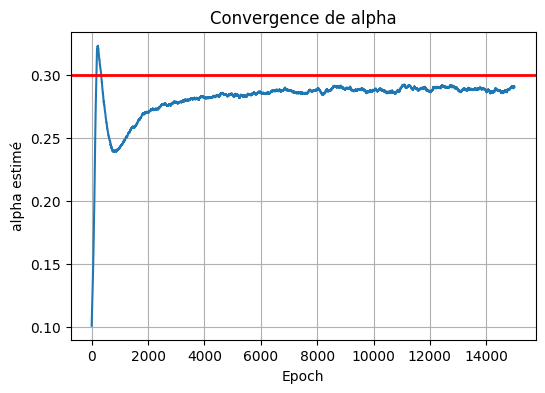

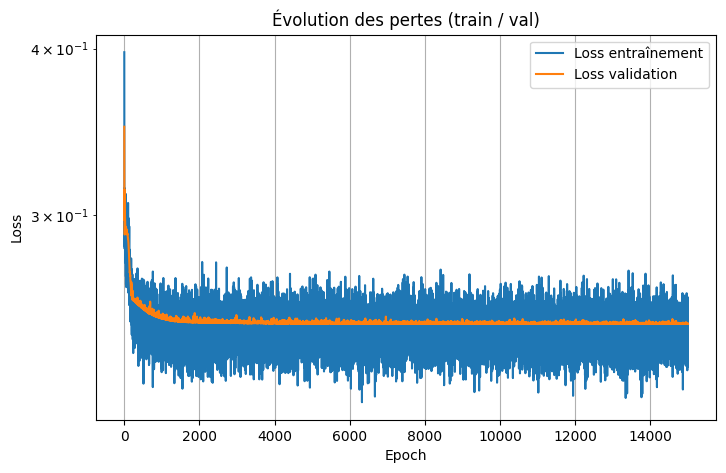

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(alpha_history, label="alpha estimé")
plt.axhline(y=0.3, color='red', linewidth=2, label="alpha réel = 0.3")

plt.xlabel("Epoch")
plt.ylabel("alpha estimé")
plt.title("Convergence de alpha")
plt.grid(True)
plt.savefig("convergencealpha.png", dpi=300, bbox_inches='tight')
plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Loss entraînement")
plt.plot(val_loss_history, label="Loss validation")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Évolution des pertes (train / val)")
plt.legend()
plt.grid(True)
plt.savefig("trainvsvalid.png", dpi=300, bbox_inches='tight')
plt.show()




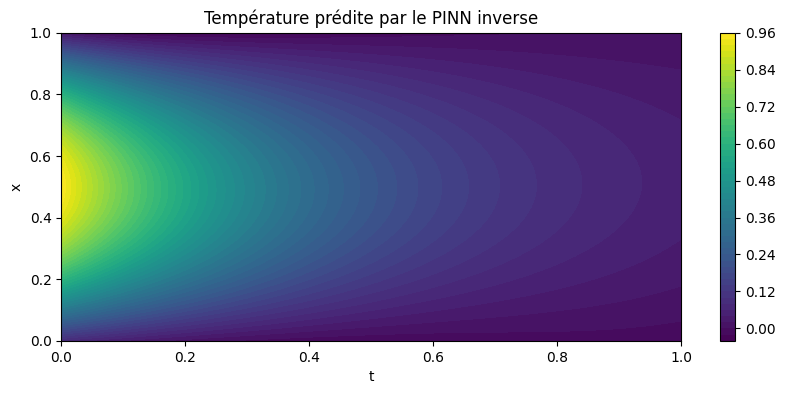

In [13]:
# ================================
#  Carte de la température PINN inverse
# ================================

# Reconstruction complète
t_full = torch.tensor(t_all, dtype=torch.float32).reshape(-1,1).to(device)
x_full = torch.tensor(x_all, dtype=torch.float32).reshape(-1,1).to(device)

with torch.no_grad():
    u_pinn_full = model(t_full, x_full).cpu().numpy().reshape(TT.shape)

plt.figure(figsize=(10,4))
plt.contourf(TT, XX, u_pinn_full, 50)
plt.colorbar()
plt.xlabel("t")
plt.ylabel("x")
plt.title("Température prédite par le PINN inverse")
plt.savefig("température.png", dpi=300, bbox_inches='tight')
plt.show()


## Conclusion

Le PINN a permis d'estimer le paramètre physique \(\alpha\) à partir de données de température bruitées.

Ce résultat montre que les Physics-Informed Neural Networks permettent de résoudre des **problèmes inverses**, c'est-à-dire retrouver des paramètres physiques inconnus à partir de données expérimentales.

Cette approche combine :

- les données
- les équations physiques
- l'apprentissage profond